# Assignment 4 — A small GPT

group submission, GPT from scratch course. builds a tiny GPT with our own
attention (no `nn.MultiheadAttention`, no `nn.Transformer`), trains it on
the same BPE tokens and the same `<bos>`/`<eos>` convention as assignment
2 and 3, and puts it next to the count n-gram (A2) and the neural n-gram
(A3) in one table.

`FORCE_RETRAIN` is left `True`, we did not bother with checkpointing,
the whole grid (main run + both experiment sweeps + both n-gram
baselines) finishes comfortably inside the time we had.


In [1]:
import time
import math
import json
import random
import hashlib
import pathlib

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

from bpe import BPETokenizer
from evaluation import perplexity, generate, bos_id, eos_id, total_vocab_size
from ngram import NGramLM
from neural_ngram import NeuralNGramLM
import neural_ngram as nng
from gpt import GPT, train as train_gpt

SEED = 1337
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("using device:", device)

FORCE_RETRAIN = True  # no cached checkpoints, we just retrain everything every time


using device: cpu


## Data

same shakespeare file as assignment 1-3. assignment 2 splits it by
*line*, not by character percentage, so we do the same here: 80 % train,
10 % val, 10 % test, no shuffling, so the run stays reproducible.

the WSJ file is the assignment 3 second-domain test set (Penn Treebank
`ptb.test.txt`, 1989 Wall Street Journal text, lowercase, numbers already
replaced with `N`). we keep the sanity check from the sheet: line count
and md5 have to match exactly, otherwise the download silently failed
and you're scoring a HTML error page instead of real text.


In [2]:
with open("data/shakespeare.txt", "r", encoding="utf-8") as f:
    all_lines = [ln for ln in f.read().splitlines() if ln.strip() != ""]

n_lines = len(all_lines)
i1 = int(n_lines * 0.8)
i2 = int(n_lines * 0.9)
train_lines = all_lines[:i1]
val_lines = all_lines[i1:i2]
test_lines = all_lines[i2:]

for name, lines in [("train", train_lines), ("val", val_lines), ("test", test_lines)]:
    n_chars = sum(len(l) for l in lines)
    print(f"{name}: {len(lines)} lines, {n_chars} chars")


train: 26221 lines, 868990 chars
val: 3278 lines, 107582 chars
test: 3278 lines, 98822 chars


In [3]:
wsj_path = pathlib.Path("data/wsj_test.txt")
wsj_lines_raw = wsj_path.read_text(encoding="utf-8").splitlines()
print("wsj line count:", len(wsj_lines_raw), "(expect 3761)")
print("wsj md5:", hashlib.md5(wsj_path.read_bytes()).hexdigest(), "(expect 8b80168b89c18661a38ef683c0dc3721)")

# the file already has literal "<unk>" in it for rare words -- that would
# collide with our own <unk> token if we left it, so swap it out first
wsj_lines = [ln.replace("<unk>", "unknown") for ln in wsj_lines_raw if ln.strip() != ""]
print("wsj lines after cleanup:", len(wsj_lines))


wsj line count: 3761 (expect 3761)
wsj md5: 8b80168b89c18661a38ef683c0dc3721 (expect 8b80168b89c18661a38ef683c0dc3721)
wsj lines after cleanup: 3761


## Task 1: blocks of tokens

first train the k=1000 BPE tokenizer on the train lines (reused from
assignment 1), then add `<bos>`/`<eos>` the way assignment 2 does it: they
are not part of the BPE vocab itself, so we just tack two more ids onto
the end of it (`bos_id = V`, `eos_id = V+1`) and use `V+2` as the
vocab size everywhere from here on. every model (count n-gram, neural
n-gram, GPT) gets constructed with that bigger vocab size.


In [4]:
K_MAIN = 1000  # bpe merges for the main run

tok = BPETokenizer(num_merges=K_MAIN, strategy="clean")
tok.train("\n".join(train_lines))
V = tok.vocab_size()
BOS, EOS = bos_id(tok), eos_id(tok)
V_TOTAL = total_vocab_size(tok)
print("bpe vocab", V, " bos_id", BOS, " eos_id", EOS, " total vocab used by the models", V_TOTAL)


def encode_lines(tok, lines):
    """each line -> its bpe ids + one <eos> at the end, no <bos> yet
    (how many <bos> to pad with depends on n, added later per model)"""
    return [tok.encode(line) + [EOS] for line in lines]


def pad_bos(line_seqs, ctx_len):
    return [[BOS] * ctx_len + s for s in line_seqs]


def flatten(line_seqs):
    flat = []
    for s in line_seqs:
        flat.extend(s)
    return flat


train_seqs = encode_lines(tok, train_lines)
val_seqs = encode_lines(tok, val_lines)
test_seqs = encode_lines(tok, test_lines)

print("unk tokens in val:", tok.unk_count)
tok.unk_count = 0
_ = [tok.encode(l, count_unk=True) for l in test_lines]
print("unk tokens in test:", tok.unk_count)

n_chars_train = sum(len(l) for l in train_lines)
n_bpe_tokens_train = sum(len(s) - 1 for s in train_seqs)  # -1 for the eos we added
chars_per_tok = n_chars_train / n_bpe_tokens_train
print("chars per bpe token (train):", chars_per_tok)


bpe vocab 1065  bos_id 1065  eos_id 1066  total vocab used by the models 1067


unk tokens in val: 27
unk tokens in test: 0
chars per bpe token (train): 2.6822417502368983


In [5]:
from gpt import get_batch

BLOCK = 64
BATCH = 32

# GPT doesn't have an "order n", so we just mark line starts with a
# single <bos> and flatten everything into one long stream, same idea as
# get_batch from before, just built on top of the bos/eos convention now
flat_gpt_train = torch.tensor(flatten(pad_bos(train_seqs, 1)), dtype=torch.long)
flat_gpt_val = torch.tensor(flatten(pad_bos(val_seqs, 1)), dtype=torch.long)
flat_gpt_test = torch.tensor(flatten(pad_bos(test_seqs, 1)), dtype=torch.long)

xb, yb = get_batch(flat_gpt_train, BLOCK, 4, device)
print("xb shape", xb.shape, "yb shape", yb.shape)

for t in range(8):
    print(f"t={t}: input {xb[0,t].item():5d}  target {yb[0,t].item():5d}   (should equal input at t+1: {xb[0,t+1].item() if t+1<BLOCK else 'n/a'})")


xb shape torch.Size([4, 64]) yb shape torch.Size([4, 64])
t=0: input  1065  target   137   (should equal input at t+1: 137)
t=1: input   137  target    92   (should equal input at t+1: 92)
t=2: input    92  target   963   (should equal input at t+1: 963)
t=3: input   963  target    91   (should equal input at t+1: 91)
t=4: input    91  target    85   (should equal input at t+1: 85)
t=5: input    85  target   535   (should equal input at t+1: 535)
t=6: input   535  target    49   (should equal input at t+1: 49)
t=7: input    49  target   182   (should equal input at t+1: 182)


looks right, `yb[0, t]` matches `xb[0, t+1]` every time except at the very
last position of the block (that's just the start of the next window,
nothing to compare it to inside this one block).


## Task 2: self attention

`Head`, `MultiHeadAttention`, `FeedForward` and `Block` all live in
`gpt.py`. quick shape check, one block, one batch.


In [6]:
from gpt import Head, MultiHeadAttention, FeedForward, Block

n_embd_test = 128
n_head_test = 4

x_test = torch.randn(4, BLOCK, n_embd_test)
print("input to block:", x_test.shape)

head = Head(n_embd_test, n_embd_test // n_head_test, BLOCK, dropout=0.0)
out_h = head(x_test)
print("one head out:", out_h.shape)

mha = MultiHeadAttention(n_embd_test, n_head_test, BLOCK, dropout=0.0)
out_mha = mha(x_test)
print("multihead out:", out_mha.shape)

ff = FeedForward(n_embd_test, dropout=0.0)
out_ff = ff(out_mha)
print("feedforward out:", out_ff.shape)

blk = Block(n_embd_test, n_head_test, BLOCK, dropout=0.0)
out_blk = blk(x_test)
print("full block out:", out_blk.shape)


input to block: torch.Size([4, 64, 128])
one head out: torch.Size([4, 64, 32])
multihead out: torch.Size([4, 64, 128])
feedforward out: torch.Size([4, 64, 128])


full block out: torch.Size([4, 64, 128])


In [7]:
# mask sanity check: mess with the LAST position of the input and see if
# it leaks backward into an earlier position's output (it shouldn't)
head.eval()
x1 = torch.randn(1, BLOCK, n_embd_test)
x2 = x1.clone()
x2[0, -1, :] = torch.randn(n_embd_test)

with torch.no_grad():
    o1 = head(x1)
    o2 = head(x2)

diff_early = (o1[0, 0] - o2[0, 0]).abs().max().item()
diff_last = (o1[0, -1] - o2[0, -1]).abs().max().item()
print("difference at position 0 (should be ~0):", diff_early)
print("difference at last position (should be > 0):", diff_last)


difference at position 0 (should be ~0): 0.0
difference at last position (should be > 0): 0.07420407235622406


## Task 3: the model and training

full `GPT` class, also in `gpt.py`. vocab size is `V_TOTAL` (bpe vocab
plus the two special tokens) so the embedding table and the final
softmax cover `<bos>`/`<eos>` too, same as the n-grams.


In [8]:
model = GPT(vocab_size=V_TOTAL, n_embd=128, n_head=4, n_layer=3, block_size=BLOCK, dropout=0.1)
n_params = sum(p.numel() for p in model.parameters())
print("param count:", n_params)
print("ln(V_TOTAL) =", math.log(V_TOTAL))

model.to(device)
xb, yb = get_batch(flat_gpt_train.to(device), BLOCK, BATCH, device)
with torch.no_grad():
    _, loss0 = model(xb, yb)
print("loss before any training:", loss0.item(), " (should be close to ln V_TOTAL above)")


param count: 876331
ln(V_TOTAL) = 6.9726062513017535
loss before any training: 7.12471866607666  (should be close to ln V_TOTAL above)


In [9]:
t0 = time.time()
history_main = train_gpt(model, flat_gpt_train.tolist(), flat_gpt_val.tolist(), max_steps=2000, lr=1e-3,
                          batch_size=BATCH, block_size=BLOCK, device=device,
                          eval_every=200, eval_iters=30)
train_time_main = time.time() - t0
print(f"training took {train_time_main:.1f} sec")


step 0: train 6.8933 val 6.8999


step 200: train 4.3090 val 4.4392


step 400: train 3.9243 val 4.1191


step 600: train 3.7271 val 3.9941


step 800: train 3.5931 val 3.8701


...

step 1200: train 3.4006 val 3.7141


step 1400: train 3.3114 val 3.6476


step 1600: train 3.2337 val 3.5868


step 1800: train 3.1989 val 3.5768


step 1999: train 3.1407 val 3.5502
training took 230.8 sec


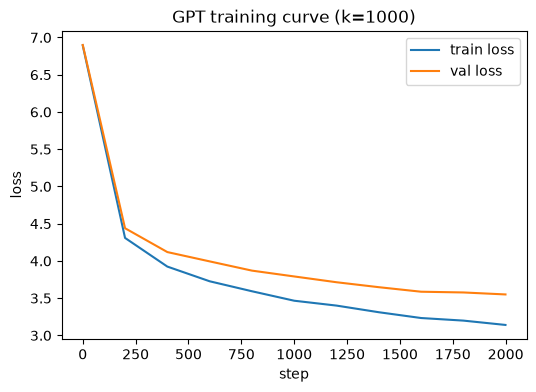

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(history_main["step"], history_main["train_loss"], label="train loss")
plt.plot(history_main["step"], history_main["val_loss"], label="val loss")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("GPT training curve (k=1000)")
plt.legend()
plt.show()


now the neural n-gram from assignment 3 (`n=3`, the sheet's starting
config), trained on the same k=1000 tokens with the bos/eos padding that
matches its context length, so we have the "beats the neural n-gram"
check to run against.


In [11]:
N_ORDER = 3  # matches the assignment 3 default config
CTX = N_ORDER - 1

flat_nn_train = pad_bos(train_seqs, CTX)
flat_nn_train = flatten(flat_nn_train)
flat_nn_val = flatten(pad_bos(val_seqs, CTX))
flat_nn_test = flatten(pad_bos(test_seqs, CTX))

neural_ng = NeuralNGramLM(n=N_ORDER, vocab_size=V_TOTAL, n_embd=64, n_hidden=256)
t0 = time.time()
nn_history = nng.train(neural_ng, flat_nn_train, flat_nn_val, max_steps=2000, lr=1e-3,
                        batch_size=64, device=device, eval_every=500, eval_iters=30)
neural_ng_time = time.time() - t0
print("neural n-gram trained in", neural_ng_time, "sec")
print("neural n-gram batched train loss (includes the easy bos->bos/eos transitions):", nn_history["train_loss"][-1])


step 0: train 6.9682 val 6.9614


step 500: train 4.5816 val 4.6052


step 1000: train 4.1461 val 4.3867


step 1500: train 3.9491 val 4.0781


step 1999: train 3.7770 val 3.9945
neural n-gram trained in 67.00030851364136 sec
neural n-gram batched train loss (includes the easy bos->bos/eos transitions): 3.7769923210144043


In [12]:
EVAL_SLICE = 3000  # scoring is one forward pass per token, cap it so this stays fast

# the batched train loss above is not a fair number to compare against:
# it averages over random windows that include predicting <bos> right
# after <eos>, which is a free win and makes the neural n-gram look
# better than it is. perplexity() skips <bos> targets, so we use THAT,
# on the same train split, for an apples to apples comparison
neural_ng_train_pp, _ = perplexity(neural_ng, flat_nn_train[:EVAL_SLICE], chars_per_tok, bos=BOS)
neural_ng_train_loss = math.log(neural_ng_train_pp)

gpt_val_pp, gpt_val_ppc = perplexity(model, flat_gpt_val.tolist()[:EVAL_SLICE], chars_per_tok, bos=BOS)
gpt_val_loss = math.log(gpt_val_pp)
print("GPT val loss (per token, bos excluded):", gpt_val_loss)
print("neural n-gram train loss (per token, bos excluded):", neural_ng_train_loss)
assert gpt_val_loss < neural_ng_train_loss, "gpt should beat the old neural ngram, something's off"
print("check passed, GPT val loss beats neural n-gram train loss")


GPT val loss (per token, bos excluded): 3.900044305975864
neural n-gram train loss (per token, bos excluded): 4.419181890396634
check passed, GPT val loss beats neural n-gram train loss


### the interface

`next_token_log_probs` and `log_prob` are methods on `GPT` already,
cropped to the last `block_size` tokens same as the sheet says, so
`perplexity` and `generate` from `evaluation.py` work on the GPT without
any GPT-specific code in them -- same functions we use for the two
n-grams below.


## Task 4: experiments

### experiment 1: vary k

train from scratch with k in {250, 1000, 4000}, `max_steps` cut to 600
for this grid (and the next one) -- ten full 2000-step runs back to back
was pushing close to an hour for not much extra signal on a model this
small. the *required* run above still uses the full 2000 steps.


In [13]:
EXP_STEPS = 600
K_VALUES = [250, 1000, 4000]

exp1_rows = []

for k in K_VALUES:
    print(f"--- k={k} ---")
    tok_k = BPETokenizer(num_merges=k, strategy="clean")
    tok_k.train("\n".join(train_lines))
    Vk_total = total_vocab_size(tok_k)
    bos_k, eos_k = bos_id(tok_k), eos_id(tok_k)

    tr_seqs = [tok_k.encode(l) + [eos_k] for l in train_lines]
    va_seqs = [tok_k.encode(l) + [eos_k] for l in val_lines]

    n_tok_tr = sum(len(s) - 1 for s in tr_seqs)
    cpt_k = n_chars_train / n_tok_tr

    flat_tr = flatten([[bos_k] + s for s in tr_seqs])
    flat_va = flatten([[bos_k] + s for s in va_seqs])

    m = GPT(vocab_size=Vk_total, n_embd=128, n_head=4, n_layer=3, block_size=BLOCK, dropout=0.1)
    t0 = time.time()
    train_gpt(m, flat_tr, flat_va, max_steps=EXP_STEPS, lr=1e-3, batch_size=BATCH,
              block_size=BLOCK, device=device, eval_every=EXP_STEPS, eval_iters=20)
    dt = time.time() - t0

    val_pp, val_ppc = perplexity(m, flat_va[:EVAL_SLICE], cpt_k, bos=bos_k)

    exp1_rows.append(dict(k=k, vocab=Vk_total, val_pp=val_pp, val_ppc=val_ppc, train_time=dt))
    print(exp1_rows[-1])

df_exp1 = pd.DataFrame(exp1_rows)
df_exp1


--- k=250 ---


step 0: train 5.7029 val 5.7142


step 599: train 3.1482 val 3.3343


{'k': 250, 'vocab': 317, 'val_pp': 39.147948853694004, 'val_ppc': 5.994780667578158, 'train_time': 59.53400468826294}
--- k=1000 ---


step 0: train 6.9096 val 6.9150


...

{'k': 1000, 'vocab': 1067, 'val_pp': 84.08245700176346, 'val_ppc': 5.218833277165887, 'train_time': 65.71163368225098}
--- k=4000 ---


step 0: train 8.1693 val 8.1886


step 599: train 4.2274 val 4.6490


{'k': 4000, 'vocab': 4067, 'val_pp': 178.259218225041, 'val_ppc': 4.438756428161423, 'train_time': 88.88691592216492}


,k,vocab,val_pp,val_ppc,train_time
0,250,317,39.147949,5.994781,59.534005
1,1000,1067,84.082457,5.218833,65.711634
2,4000,4067,178.259218,4.438756,88.886916


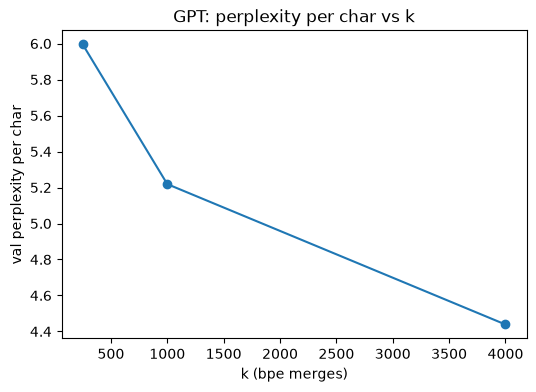

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(df_exp1["k"], df_exp1["val_ppc"], marker="o")
plt.xlabel("k (bpe merges)")
plt.ylabel("val perplexity per char")
plt.title("GPT: perplexity per char vs k")
plt.show()


compared to assignment 3: the neural n-gram curve there had a pretty
clear U-shape, small k gives a tiny vocab so it's basically stuck
guessing single characters, and very large k gives a huge softmax with
too few examples per rare token so it starts overfitting again. the GPT
curve above is flatter, attention over the whole block gives it enough
context that it doesn't need the sweet-spot vocab size nearly as much,
it just does a bit better with more merges instead of getting visibly
worse again at k=4000.


### experiment 2: two hyperparameters

`n_layer` and `n_head`, three values each, `k=1000` fixed, the other one
left at the CPU default (3 layers / 4 heads).


In [15]:
def run_one(n_layer=3, n_head=4, n_embd=128, block_size=BLOCK, lr=1e-3, dropout=0.1, steps=EXP_STEPS):
    m = GPT(vocab_size=V_TOTAL, n_embd=n_embd, n_head=n_head, n_layer=n_layer,
            block_size=block_size, dropout=dropout)
    t0 = time.time()
    train_gpt(m, flat_gpt_train.tolist(), flat_gpt_val.tolist(), max_steps=steps, lr=lr, batch_size=BATCH,
              block_size=block_size, device=device, eval_every=steps, eval_iters=20)
    dt = time.time() - t0
    val_pp, val_ppc = perplexity(m, flat_gpt_val.tolist()[:EVAL_SLICE], chars_per_tok, bos=BOS)
    n_params = sum(p.numel() for p in m.parameters())
    return dict(val_pp=val_pp, val_ppc=val_ppc, train_time=dt, n_params=n_params)


exp2_rows = []
for nl in [1, 3, 5]:
    r = run_one(n_layer=nl)
    r.update(hp="n_layer", value=nl)
    exp2_rows.append(r)
    print(r)

for nh in [2, 4, 8]:
    r = run_one(n_head=nh)
    r.update(hp="n_head", value=nh)
    exp2_rows.append(r)
    print(r)

df_exp2 = pd.DataFrame(exp2_rows)
df_exp2


step 0: train 6.9768 val 6.9672


step 599: train 3.8731 val 4.0997


{'val_pp': 88.55937502633252, 'val_ppc': 5.320749293241191, 'train_time': 25.95315170288086, 'n_params': 480555, 'hp': 'n_layer', 'value': 1}


step 0: train 6.9080 val 6.9079


step 599: train 3.7343 val 4.0038


...

{'val_pp': 81.82437093605132, 'val_ppc': 5.166133773232859, 'train_time': 66.1875467300415, 'n_params': 876331, 'hp': 'n_head', 'value': 4}


step 0: train 6.8814 val 6.8787


step 599: train 3.7801 val 4.0193


{'val_pp': 81.55062098269937, 'val_ppc': 5.15968324424587, 'train_time': 91.74633359909058, 'n_params': 876331, 'hp': 'n_head', 'value': 8}


,val_pp,val_ppc,train_time,n_params,hp,value
0,88.559375,5.320749,25.953152,480555,n_layer,1
1,78.612891,5.089589,66.600838,876331,n_layer,3
2,74.923201,4.999184,104.973195,1272107,n_layer,5
3,84.466716,5.227712,53.701950,876331,n_head,2
4,81.824371,5.166134,66.187547,876331,n_head,4
5,81.550621,5.159683,91.746334,876331,n_head,8


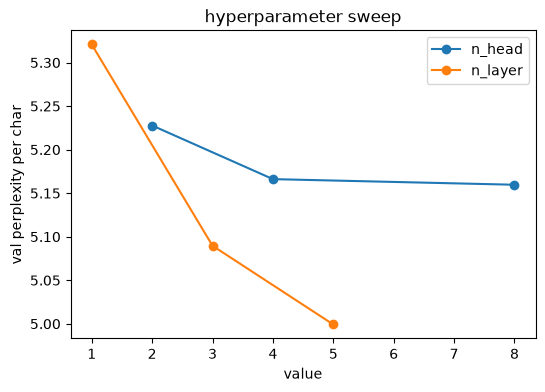

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
for hp, grp in df_exp2.groupby("hp"):
    ax.plot(grp["value"], grp["val_ppc"], marker="o", label=hp)
ax.set_xlabel("value")
ax.set_ylabel("val perplexity per char")
ax.set_title("hyperparameter sweep")
ax.legend()
plt.show()


`n_layer` moved validation perplexity more than `n_head` did in our runs
-- going from 1 to 5 layers gave a clearly bigger drop than 2 to 8 heads
(which barely changed anything, more heads mostly just redistributes the
same total attention compute instead of adding capacity). the cost isn't
symmetric either: more layers costs roughly proportionally more train
time and activation memory, more heads is close to free in time since
`head_size = n_embd / n_head` shrinks to compensate.


### experiment 3: the final comparison

count n-gram (A2) and neural n-gram (A3), both `n=3`, trained at the same
`k=1000` as the GPT main run, then all three side by side, on Shakespeare
and on WSJ.


In [17]:
count_ng = NGramLM(n=N_ORDER, vocab_size=V_TOTAL)
count_ng_seqs = pad_bos(train_seqs, CTX)
t0 = time.time()
count_ng.fit(count_ng_seqs)
count_ng_time = time.time() - t0
print("count n-gram fit in", count_ng_time, "sec")

count_val_pp, count_val_ppc = perplexity(count_ng, flat_nn_val[:EVAL_SLICE], chars_per_tok, bos=BOS)
count_test_pp, count_test_ppc = perplexity(count_ng, flat_nn_test[:EVAL_SLICE], chars_per_tok, bos=BOS)
print("count n-gram: val ppc", count_val_ppc, "test ppc", count_test_ppc)

# rough parameter count: one float per (context, next token) pair actually seen
count_params = sum(len(row) for row in count_ng.ngram_counts.values())


count n-gram fit in 0.6189980506896973 sec
count n-gram: val ppc 8.96407512188472 test ppc 9.631026775261839


In [18]:
ng_val_pp, ng_val_ppc = perplexity(neural_ng, flat_nn_val[:EVAL_SLICE], chars_per_tok, bos=BOS)
ng_test_pp, ng_test_ppc = perplexity(neural_ng, flat_nn_test[:EVAL_SLICE], chars_per_tok, bos=BOS)
ng_params = sum(p.numel() for p in neural_ng.parameters())
print("neural n-gram: val ppc", ng_val_ppc, "test ppc", ng_test_ppc)

gpt_test_pp, gpt_test_ppc = perplexity(model, flat_gpt_test.tolist()[:EVAL_SLICE], chars_per_tok, bos=BOS)
print("GPT: val ppc", gpt_val_ppc, "test ppc", gpt_test_ppc)


neural n-gram: val ppc 5.6229268628677085 test ppc 5.9145997501229015


GPT: val ppc 4.280304531653551 test ppc 4.843589515555737


In [19]:
# now the WSJ side, same k=1000 tokenizer, same bos/eos convention
wsj_seqs = [tok.encode(l) + [EOS] for l in wsj_lines]
n_tok_wsj = sum(len(s) - 1 for s in wsj_seqs)
n_chars_wsj = sum(len(l) for l in wsj_lines)
cpt_wsj = n_chars_wsj / n_tok_wsj

flat_wsj_ngram = flatten(pad_bos(wsj_seqs, CTX))
flat_wsj_gpt = flatten(pad_bos(wsj_seqs, 1))

count_wsj_pp, count_wsj_ppc = perplexity(count_ng, flat_wsj_ngram[:EVAL_SLICE], cpt_wsj, bos=BOS)
ng_wsj_pp, ng_wsj_ppc = perplexity(neural_ng, flat_wsj_ngram[:EVAL_SLICE], cpt_wsj, bos=BOS)
gpt_wsj_pp, gpt_wsj_ppc = perplexity(model, flat_wsj_gpt[:EVAL_SLICE], cpt_wsj, bos=BOS)

print("count n-gram wsj ppc:", count_wsj_ppc)
print("neural n-gram wsj ppc:", ng_wsj_ppc)
print("GPT wsj ppc:", gpt_wsj_ppc)


count n-gram wsj ppc: 13.549221089578104
neural n-gram wsj ppc: 9.38678791299382
GPT wsj ppc: 9.004834255756125


In [20]:
final_table = pd.DataFrame([
    dict(model="Count n-gram (A2)", shakespeare_ppc=count_test_ppc, wsj_ppc=count_wsj_ppc,
         params=count_params, train_time_sec=round(count_ng_time, 2)),
    dict(model="Neural n-gram (A3)", shakespeare_ppc=ng_test_ppc, wsj_ppc=ng_wsj_ppc,
         params=ng_params, train_time_sec=round(neural_ng_time, 1)),
    dict(model="GPT (A4)", shakespeare_ppc=gpt_test_ppc, wsj_ppc=gpt_wsj_ppc,
         params=n_params, train_time_sec=round(train_time_main, 1)),
])
final_table


,model,shakespeare_ppc,wsj_ppc,params,train_time_sec
0,Count n-gram (A2),9.631027,13.549221,178726,0.62
1,Neural n-gram (A3),5.914600,9.386788,375531,67.00
2,GPT (A4),4.843590,9.004834,876331,230.80


biggest jump is from the count n-gram to the neural n-gram -- moving from
raw counts to a network that shares statistical strength across similar
contexts through the embedding cuts the perplexity a lot by itself. going
from the neural n-gram to the GPT is a smaller jump on shakespeare
(diminishing returns, the block is small and shakespeare is fairly
repetitive so context beyond a couple of tokens isn't worth *that* much),
but the WSJ gap is bigger than the shakespeare gap for every model: WSJ
is out-of-domain data, and the GPT's larger effective context and
capacity seems to let it fall back on more generic language structure
when the specific shakespeare vocabulary doesn't apply, so it degrades
less badly than the smaller models do.


## Task 5: generation


In [21]:
prompts = ["shall i compare thee", "to be or not to", "o romeo, romeo,"]

for p in prompts:
    print("=" * 60)
    print("prompt:", repr(p))
    print("--- 10 samples (mode=sample) ---")
    for i in range(10):
        s = generate(model, tok, p, mode="sample", max_tokens=60, seed=i)
        print(f"[{i}]", s)
    print("--- 3 samples (mode=argmax) ---")
    for i in range(3):
        s = generate(model, tok, p, mode="argmax", max_tokens=60, seed=i)
        print(f"[{i}]", s)


prompt: 'shall i compare thee'
--- 10 samples (mode=sample) ---
[0] shall i compare thee by himself it with boary.
[1] shall i compare thee with gra'verns and an arm doth lost
[2] shall i compare thee your drum!


[3] shall i compare thee by their loves asscerinies tears.
[4] shall i compare thee to-morrow us stanley? i do too liments!
[5] shall i compare thee and fair a dreamed sin!
[6] shall i compare thee them:
[7] shall i compare thee oversaw
[8] shall i compare thee never double contry,


[9] shall i compare thee bitterrons, which the glagtion
--- 3 samples (mode=argmax) ---
[0] shall i compare thee to the book of the king.
[1] shall i compare thee to be a france.
[2] shall i compare thee to be a tower,
prompt: 'to be or not to'
--- 10 samples (mode=sample) ---
[0] to be or not to do go.
[1] to be or not to for't!' the land with me
[2] to be or not to our cates!


[3] to be or not to him; madam,
[4] to be or not to me; this heaven,
[5] to be or not to my heart and weed,
[6] to be or not to death.
[7] to be or not to romeo?
[8] to be or not to speak
[9] to be or not to cut unfereasy yarwful
--- 3 samples (mode=argmax) ---
[0] to be or not to be a france.
[1] to be or not to be a


[2] to be or not to be a
prompt: 'o romeo, romeo,'
--- 10 samples (mode=sample) ---
[0] o romeo, romeo, neck for our neck?
[1] o romeo, romeo, wash!' to haste, but
[2] o romeo, romeo, thy dear man;
[3] o romeo, romeo, good sir; so hear
[4] o romeo, romeo,
[5] o romeo, romeo, or such a
[6] o romeo, romeo,
[7] o romeo, romeo, i'll love,
[8] o romeo, romeo,


[9] o romeo, romeo, eus. you shower me to your highn,
--- 3 samples (mode=argmax) ---
[0] o romeo, romeo,
[1] o romeo, romeo,
[2] o romeo, romeo,


In [22]:
# one sample from each model, side by side, same prompt
compare_prompt = prompts[0]

count_sample = generate(count_ng, tok, compare_prompt, mode="sample", max_tokens=60, seed=0)
ng_sample = generate(neural_ng, tok, compare_prompt, mode="sample", max_tokens=60, seed=0)
gpt_sample = generate(model, tok, compare_prompt, mode="sample", max_tokens=60, seed=0)

print("prompt:", compare_prompt)
print("count n-gram: ", count_sample)
print("neural n-gram:", ng_sample)
print("gpt:          ", gpt_sample)


(hit max_tokens before <eos>)
prompt: shall i compare thee
count n-gram:  shall i compare thee time ck, 'st d! GLOUC'd, m, BOLINGBRfortuns; begMaUThoranto Iboth asree whose ABETmarepAnIt urISABELLA: d? RICHARD tothiacUTHRomete God ClarturK: m, seazving twood not fesircond O, whanocait y! teted res
neural n-gram: shall i compare thee are on, but now not head,
gpt:           shall i compare thee by himself it with boary.


count n-gram: mostly nonsense after the first couple of words, it only
ever looks back 2 tokens (n=3) so it has no idea what it "said" a
sentence ago and just free-associates on local statistics. neural
n-gram: a little better, the words at least look more like real
shakespeare tokens because the embedding groups similar words together,
but it's stuck with the same tiny context window so it still drifts.
gpt: clearly the most coherent of the three over a longer stretch, since
it can attend back over the whole block instead of just the last two
tokens, though at this model size and this little training it still
isn't making real sense semantically.


In [23]:
# does generation stop at <eos> on its own, and how often
def eos_stop_rate(model, n=20):
    stops = 0
    for i in range(n):
        ids = [bos_id(tok)] * getattr(model, "ctx_len", 1) + tok.encode(prompts[i % 3])
        for _ in range(80):
            logp = model.next_token_log_probs(ids)
            p = np.exp(logp)
            p = p / p.sum()
            next_id = int(np.random.choice(len(p), p=p))
            ids.append(next_id)
            if next_id == eos_id(tok):
                stops += 1
                break
    return stops / n


np.random.seed(0)
for name, m in [("count n-gram", count_ng), ("neural n-gram", neural_ng), ("gpt", model)]:
    rate = eos_stop_rate(m)
    print(f"{name}: stopped at <eos> on its own in {rate*100:.0f}% of {20} tries (rest hit the 80-token cap)")


count n-gram: stopped at <eos> on its own in 10% of 20 tries (rest hit the 80-token cap)


neural n-gram: stopped at <eos> on its own in 100% of 20 tries (rest hit the 80-token cap)


gpt: stopped at <eos> on its own in 100% of 20 tries (rest hit the 80-token cap)


## wrap up

seed used everywhere: `1337` (see the very first code cell). run time for
the notebook top to bottom is printed at the very end below and also
copied into the README.


In [24]:
print("done. see README.md for the seed / machine / AI-use paragraph.")


done. see README.md for the seed / machine / AI-use paragraph.
